1. Import dataset from drive, so you gotta upload the file there

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)


Mounted at /content/drive


2. Load Dataset

In [2]:
CSV_PATH = "/content/drive/MyDrive/synthetic_mental_health_data.csv"
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()



Shape: (10000, 15)
Columns: ['GSR_Values', 'Age', 'Duration (minutes)', 'Timestamp', 'EEG_0', 'EEG_1', 'EEG_2', 'EEG_3', 'Preprocessed_0', 'Preprocessed_1', 'Cognitive_State', 'Emotional_State', 'Gender', 'Session_Type', 'Environmental_Context']


,GSR_Values,Age,Duration (minutes),Timestamp,EEG_0,EEG_1,EEG_2,EEG_3,Preprocessed_0,Preprocessed_1,Cognitive_State,Emotional_State,Gender,Session_Type,Environmental_Context
0,1.187530,21,41,1735780480,8.938819,3.778122,2.825354,8.087215,0.601662,0.324194,Focused,Stressed,Male,Test,Home
1,1.698264,23,41,1735813888,10.049323,3.972653,7.411741,6.410813,0.815058,0.340711,Distracted,Stressed,Male,Relaxation,Home
2,0.625261,17,37,1735759104,2.761425,0.787631,7.640270,7.960335,0.601371,0.756248,Distracted,Calm,Female,Test,Quiet Room
3,0.886407,18,35,1735849984,4.647183,4.242393,1.120041,4.208172,-0.014085,0.660563,Distracted,Calm,Male,Relaxation,Home
4,0.443970,20,32,1735774336,5.550871,3.186933,2.957123,8.422313,0.766586,1.038695,Distracted,Anxious,Male,Test,Library


3. Binary labels

Threat (1) → anxious, stressed, overloaded, distracted

Safe (0) → calm, focused

In [3]:
# Threat (1) → anxious, stressed, overloaded, distracted
# Safe (0) → calm, focused

df2 = df.copy()

# Normalize text just in case (strip spaces)
df2["Cognitive_State"] = df2["Cognitive_State"].astype(str).str.strip()

label_map = {
    # Threat
    "anxious": 1, "stressed": 1, "overloaded": 1, "distracted": 1,
    "Anxious": 1, "Stressed": 1, "Overloaded": 1, "Distracted": 1,

    # Safe
    "calm": 0, "focused": 0,
    "Calm": 0, "Focused": 0,

    # Your dataset variants (very important)
    "Cognitive Overload": 1
}

df2["y_bin"] = df2["Cognitive_State"].map(label_map)

# Drop any rows that didn't map cleanly
df2 = df2.dropna(subset=["y_bin"]).reset_index(drop=True)
df2["y_bin"] = df2["y_bin"].astype(int)

print("Binary label counts (0=Safe, 1=Threat):")
print(df2["y_bin"].value_counts())
print("\nUnique Cognitive_State values after cleanup:")
print(sorted(df2["Cognitive_State"].unique()))


Binary label counts (0=Safe, 1=Threat):
y_bin
1    7731
0    2269
Name: count, dtype: int64

Unique Cognitive_State values after cleanup:
['Cognitive Overload', 'Distracted', 'Focused']


4. Preprocessing: Categorical data --> Binary matrix

In [4]:
# Drop timestamp if present
if "Timestamp" in df2.columns:
    df2 = df2.drop(columns=["Timestamp"])

# Feature columns (adjust if needed)
base_cols = [c for c in ["GSR_Values", "Age", "Duration (minutes)"] if c in df2.columns]
eeg_cols  = [c for c in df2.columns if c.startswith("EEG_")]
prep_cols = [c for c in df2.columns if c.startswith("Preprocessed_")]
demo_cols = [c for c in ["Gender"] if c in df2.columns]  # keep for fairness later

feature_cols = base_cols + eeg_cols + prep_cols + demo_cols
print("Using features:", feature_cols)

X = df2[feature_cols].copy()

# One-hot encode categorical columns (Gender, etc.)
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

y = df2["y_bin"].values

print("X shape:", X.shape, "y shape:", y.shape)


Using features: ['GSR_Values', 'Age', 'Duration (minutes)', 'EEG_0', 'EEG_1', 'EEG_2', 'EEG_3', 'Preprocessed_0', 'Preprocessed_1', 'Gender']
X shape: (10000, 11) y shape: (10000,)


5. Train-Test split + Scaling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train counts:", pd.Series(y_train).value_counts().to_dict())
print("Test counts:", pd.Series(y_test).value_counts().to_dict())


Train: (8000, 11) Test: (2000, 11)
Train counts: {1: 6185, 0: 1815}
Test counts: {1: 1546, 0: 454}


6. Class weights for imbalance

In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:", class_weight_dict)


Class weights: {0: 2.203856749311295, 1: 0.6467259498787389}


7. Evaluation function

In [7]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

def eval_binary(name, model, X_te, y_te):
    y_pred = model.predict(X_te)

    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_te, y_pred), 4))
    print("Balanced Acc:", round(balanced_accuracy_score(y_te, y_pred), 4))
    print("Precision (Threat=1):", round(precision_score(y_te, y_pred, zero_division=0), 4))
    print("Recall (Threat=1):", round(recall_score(y_te, y_pred, zero_division=0), 4))
    print("F1 (Threat=1):", round(f1_score(y_te, y_pred, zero_division=0), 4))

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
        print("ROC-AUC:", round(roc_auc_score(y_te, y_prob), 4))

    print("\nReport:\n", classification_report(
        y_te, y_pred,
        target_names=["Safe(0)", "Threat(1)"],
        zero_division=0
    ))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

    return y_pred

8. Logistic Regression


=== Logistic Regression (balanced) ===
Accuracy: 0.7425
Balanced Acc: 0.7199
Precision (Threat=1): 0.8896
Recall (Threat=1): 0.7613
F1 (Threat=1): 0.8205
ROC-AUC: 0.8056

Report:
               precision    recall  f1-score   support

     Safe(0)       0.45      0.68      0.54       454
   Threat(1)       0.89      0.76      0.82      1546

    accuracy                           0.74      2000
   macro avg       0.67      0.72      0.68      2000
weighted avg       0.79      0.74      0.76      2000



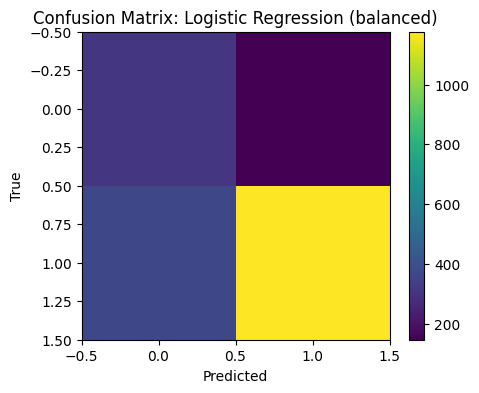

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=4000, random_state=SEED, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

y_pred_lr = eval_binary("Logistic Regression (balanced)", lr, X_test_scaled, y_test)

9. Random Forest


=== Random Forest (balanced) ===
Accuracy: 0.818
Balanced Acc: 0.6419
Precision (Threat=1): 0.8283
Recall (Threat=1): 0.9644
F1 (Threat=1): 0.8912
ROC-AUC: 0.801

Report:
               precision    recall  f1-score   support

     Safe(0)       0.72      0.32      0.44       454
   Threat(1)       0.83      0.96      0.89      1546

    accuracy                           0.82      2000
   macro avg       0.78      0.64      0.67      2000
weighted avg       0.80      0.82      0.79      2000



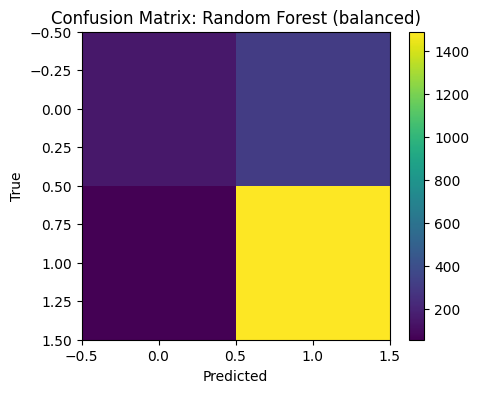

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

y_pred_rf = eval_binary("Random Forest (balanced)", rf, X_test, y_test)

10. SVM


=== SVM (RBF, balanced) ===
Accuracy: 0.746
Balanced Acc: 0.7361
Precision (Threat=1): 0.9011
Recall (Threat=1): 0.7542
F1 (Threat=1): 0.8211
ROC-AUC: 0.8184

Report:
               precision    recall  f1-score   support

     Safe(0)       0.46      0.72      0.56       454
   Threat(1)       0.90      0.75      0.82      1546

    accuracy                           0.75      2000
   macro avg       0.68      0.74      0.69      2000
weighted avg       0.80      0.75      0.76      2000



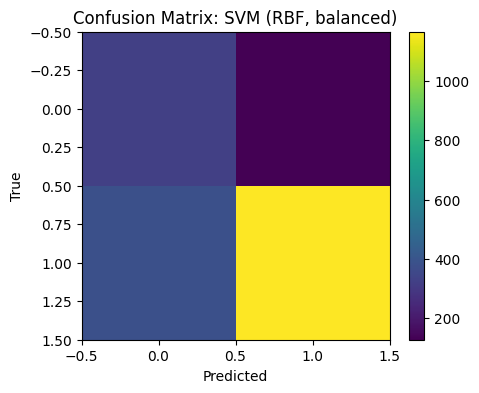

In [10]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=SEED,
    class_weight="balanced"
)
svm.fit(X_train_scaled, y_train)

y_pred_svm = eval_binary("SVM (RBF, balanced)", svm, X_test_scaled, y_test)

11.

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0



=== XGBoost (balanced) ===
Accuracy: 0.7765
Balanced Acc: 0.7061
Precision (Threat=1): 0.8705
Recall (Threat=1): 0.8351
F1 (Threat=1): 0.8524
ROC-AUC: 0.7969

Report:
               precision    recall  f1-score   support

     Safe(0)       0.51      0.58      0.54       454
   Threat(1)       0.87      0.84      0.85      1546

    accuracy                           0.78      2000
   macro avg       0.69      0.71      0.70      2000
weighted avg       0.79      0.78      0.78      2000



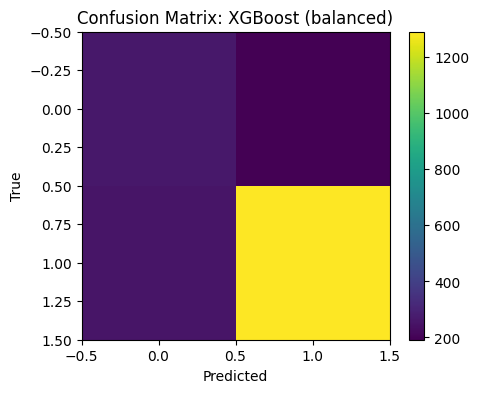

In [12]:
from xgboost import XGBClassifier

# XGBoost works well with unscaled data (tree-based)
# Use scale_pos_weight to handle class imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = eval_binary("XGBoost (balanced)", xgb, X_test, y_test)

12. MLP

In [13]:
tf.random.set_seed(SEED)

input_dim = X_train_scaled.shape[1]

mlp_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

y_prob_mlp = mlp_model.predict(X_test_scaled).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

# Quick eval
print("\n=== MLP (Keras, balanced) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Balanced Acc:", round(balanced_accuracy_score(y_test, y_pred_mlp), 4))
print("Precision (Threat=1):", round(precision_score(y_test, y_pred_mlp, zero_division=0), 4))
print("Recall (Threat=1):", round(recall_score(y_test, y_pred_mlp, zero_division=0), 4))
print("F1 (Threat=1):", round(f1_score(y_test, y_pred_mlp, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_mlp), 4))
print(classification_report(y_test, y_pred_mlp, target_names=["Safe(0)", "Threat(1)"], zero_division=0))


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6735 - loss: 0.6393 - val_accuracy: 0.7400 - val_loss: 0.5444
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7442 - loss: 0.5448 - val_accuracy: 0.7367 - val_loss: 0.5428
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7490 - loss: 0.5289 - val_accuracy: 0.7325 - val_loss: 0.5297
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7467 - loss: 0.5183 - val_accuracy: 0.7317 - val_loss: 0.5260
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7494 - loss: 0.5103 - val_accuracy: 0.7300 - val_loss: 0.5285
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7463 - loss: 0.5083 - val_accuracy: 0.7333 - val_loss: 0.5154
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7543 - loss: 0.5027 - val_accuracy: 0.7292 - val_loss: 0.5178
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7579 - loss: 0.5000 - val_accuracy: 0.7392 - val_loss:

13. 1D CNN

In [14]:
tf.random.set_seed(SEED)

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1], 1)

cnn_model = keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(64, 3, activation="relu"),
    layers.Conv1D(32, 3, activation="relu"),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

y_prob_cnn = cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

print("\n=== 1D CNN (Keras, balanced) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_cnn), 4))
print("Balanced Acc:", round(balanced_accuracy_score(y_test, y_pred_cnn), 4))
print("Precision (Threat=1):", round(precision_score(y_test, y_pred_cnn, zero_division=0), 4))
print("Recall (Threat=1):", round(recall_score(y_test, y_pred_cnn, zero_division=0), 4))
print("F1 (Threat=1):", round(f1_score(y_test, y_pred_cnn, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_cnn), 4))
print(classification_report(y_test, y_pred_cnn, target_names=["Safe(0)", "Threat(1)"], zero_division=0))

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5797 - loss: 0.6688 - val_accuracy: 0.6383 - val_loss: 0.6294
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6842 - loss: 0.6026 - val_accuracy: 0.7150 - val_loss: 0.5486
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7213 - loss: 0.5694 - val_accuracy: 0.7225 - val_loss: 0.5355
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7412 - loss: 0.5434 - val_accuracy: 0.7342 - val_loss: 0.5279
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7538 - loss: 0.5364 - val_accuracy: 0.7408 - val_loss: 0.5109
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7550 - loss: 0.5246 - val_accuracy: 0.7292 - val_loss: 0.5254
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7591 - loss: 0.5213 - val_accuracy: 0.7317 - val_loss: 0.5159
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7580 - loss: 0.5112 - val_accuracy: 0.7475 - val_los

14. Results

In [19]:
from sklearn.metrics import roc_auc_score

rows = []

def add_row(name, y_pred, y_prob=None):
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_test, y_pred),
        "Precision(Threat)": precision_score(y_test, y_pred, zero_division=0),
        "Recall(Threat)": recall_score(y_test, y_pred, zero_division=0),
        "F1(Threat)": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    })

add_row("LogReg", y_pred_lr, lr.predict_proba(X_test_scaled)[:, 1])
add_row("RandomForest", y_pred_rf, rf.predict_proba(X_test)[:, 1])
add_row("SVM", y_pred_svm, svm.predict_proba(X_test_scaled)[:, 1])
add_row("MLP", y_pred_mlp, y_prob_mlp)
add_row("XGBoost", y_pred_xgb, xgb.predict_proba(X_test)[:, 1])
add_row("1D CNN", y_pred_cnn, y_prob_cnn)

results_df = (
    pd.DataFrame(rows)
    .sort_values(by="F1(Threat)", ascending=False)
    .reset_index(drop=True)
)

results_df.style.set_caption(
    "Baseline Results: Threat = Cognitive Overload + Distracted, Safe = Focused"
)


,Model,Accuracy,Balanced_Acc,Precision(Threat),Recall(Threat),F1(Threat),ROC_AUC
0,RandomForest,0.818000,0.641904,0.828333,0.964424,0.891213,0.800993
1,XGBoost,0.776500,0.706075,0.870533,0.835058,0.852427,0.796912
2,1D CNN,0.759000,0.734429,0.895245,0.779431,0.833333,0.814934
3,SVM,0.746000,0.736133,0.901082,0.754204,0.821127,0.818350
4,LogReg,0.742500,0.719867,0.889645,0.761320,0.820495,0.805596
5,MLP,0.734500,0.728694,0.899292,0.739327,0.811502,0.823596


15. SHAP (RF)

/tmp/ipython-input-3813146425.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


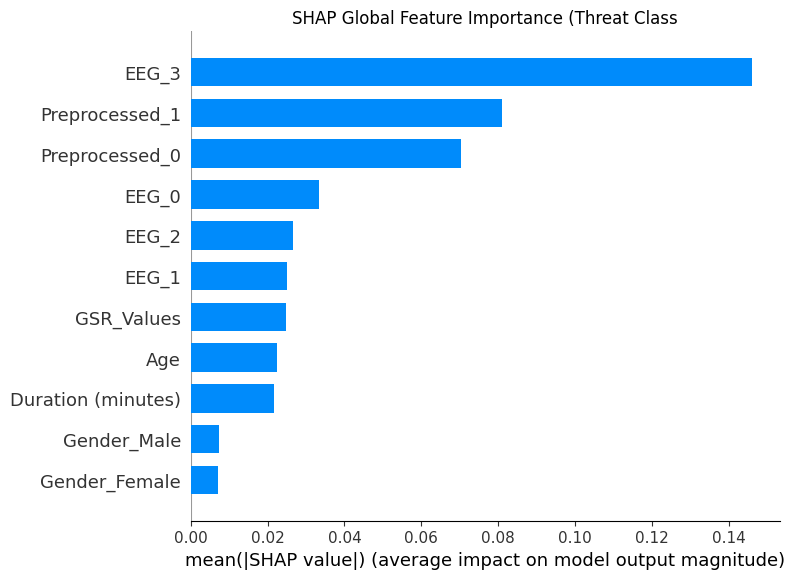

In [16]:
import shap
import matplotlib.pyplot as plt
import numpy as np

shap.initjs()

# Use the trained RF model
explainer = shap.TreeExplainer(rf)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test)

# For binary classification: index 1 = positive (Threat) class
# Correctly extract SHAP values for the positive class across all samples
shap_values_pos = shap_values[:, :, 1]

# Global SHAP summary plot (beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_pos,
    X_test,
    plot_type="bar",
    show=False
)
plt.title("SHAP Global Feature Importance (Threat Class")
plt.tight_layout()
plt.show()

15. SHAP - Male (Threat Class)

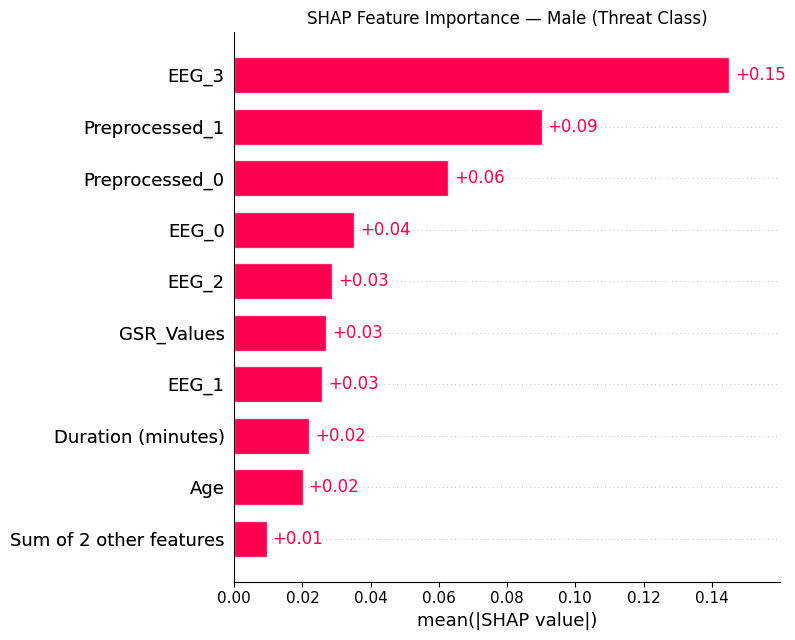

In [17]:
import shap
import matplotlib.pyplot as plt

plt.close("all")  # ✅ prevents leftover/blank figures from displaying

# --- Select Male samples ---
X_male = X_test[X_test["Gender_Male"] == 1]

MAX_SAMPLES = 500
X_male_explain = X_male.sample(n=min(MAX_SAMPLES, len(X_male)), random_state=SEED)

# --- SHAP ---
explainer = shap.TreeExplainer(rf)
sv_male = explainer(X_male_explain)

# If binary, keep Threat class (index 1)
if len(sv_male.values.shape) == 3:
    sv_male = shap.Explanation(
        values=sv_male.values[:, :, 1],
        base_values=sv_male.base_values[:, 1],
        data=sv_male.data,
        feature_names=sv_male.feature_names
    )

# ✅ show=False so SHAP doesn't auto-render a second figure
shap.plots.bar(sv_male, max_display=10, show=False)
plt.title("SHAP Feature Importance — Male (Threat Class)")
plt.tight_layout()
plt.show()


16. SHAP - Female (Threat Class)

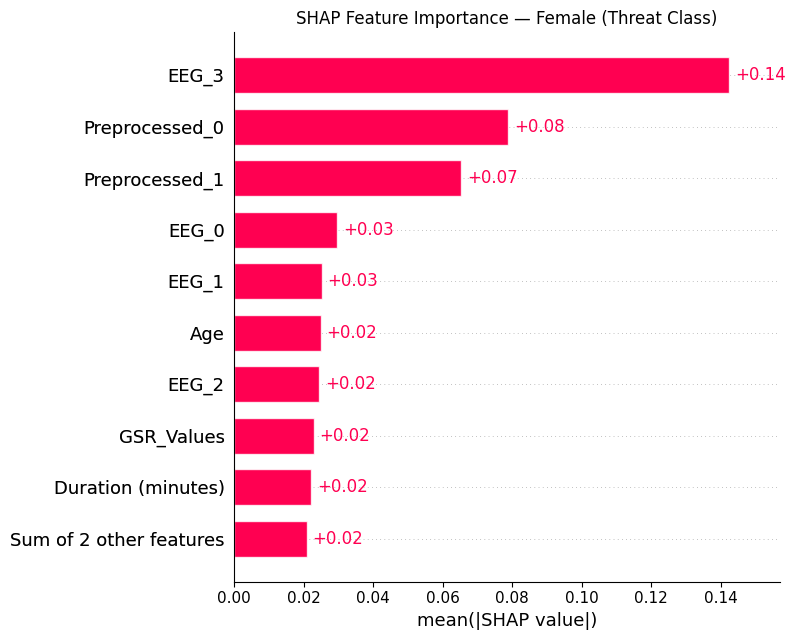

In [18]:
import shap
import matplotlib.pyplot as plt

# 🔒 Close any existing figures to avoid blank outputs
plt.close("all")

# --- Select Female samples ---
X_female = X_test[X_test["Gender_Female"] == 1]

MAX_SAMPLES = 500
X_female_explain = X_female.sample(
    n=min(MAX_SAMPLES, len(X_female)),
    random_state=SEED
)

# --- SHAP Explainer ---
explainer = shap.TreeExplainer(rf)
sv_female = explainer(X_female_explain)

# Binary classification → keep Threat class (index 1)
if len(sv_female.values.shape) == 3:
    sv_female = shap.Explanation(
        values=sv_female.values[:, :, 1],
        base_values=sv_female.base_values[:, 1],
        data=sv_female.data,
        feature_names=sv_female.feature_names
    )

# --- Plot (no auto-show, no blank figure) ---
shap.plots.bar(sv_female, max_display=10, show=False)
plt.title("SHAP Feature Importance — Female (Threat Class)")
plt.tight_layout()
plt.show()
